In [ ]:
using ITensors
using ITensorMPS
using QuanticsTCI
import TensorCrossInterpolation as TCI
using TCIITensorConversion 
using Quantics
using Plots
using NPZ
include("2D_lattice.jl") 
include("NHtk.jl")
include("extra_util.jl")

In [2]:
#The dim of hermitized Hamiltonian is 2^L
L = 4
site_1 = siteinds("Qubit", 2*L,conserve_qns=false);
site_2 = siteinds("Qubit", L,conserve_qns=false);
site_s = vcat(site_2,site_1); 

In [3]:
function novel_hop_row(Ltot,tx1,tx2,sites)
    
    xvals = range(0, (2^(Ltot) - 1); length=2^(Ltot))
    function f(x)
        fc = x % 2^L
        if fc % 2 == 0  # 偶数
            return tx1 # 偶数时的处理，这里只是示例
        else  # 奇数
            return tx2 # 奇数时的处理，这里只是示例
        end
    end
    
    qtt, ranks, errors = quanticscrossinterpolate(Float64, f,  xvals; tolerance=1e-8)
    tt = TCI.tensortrain(qtt.tci)
    density_mps = MPS(tt;sites)
    density_mpo = mps_to_diagonal_mpo(density_mps,sites);
    
    return density_mpo 
end

function novel_hop_coulmn(Ltot,ty1,ty2,sites)
    
    xvals = range(0, (2^(Ltot) - 1); length=2^(Ltot))
    
    function f(x)
        fc = x % 2^L
        sc = div(x, 2^L)
        
        if sc % 2 == 0
            return fc % 2 == 0 ? -ty1 : ty1
        else
            return fc % 2 == 0 ? -ty2 : ty2
        end
    end
    
    qtt, ranks, errors = quanticscrossinterpolate(Float64, f,  xvals; tolerance=1e-8)
    tt = TCI.tensortrain(qtt.tci)
    density_mps = MPS(tt;sites)
    density_mpo = mps_to_diagonal_mpo(density_mps,sites);
    
    return density_mpo
end
 
tx1 = 1
tx2 = 1.4
hop_intra =  novel_hop_row(2*L, tx1,tx2,site_1);
hop_inter =  novel_hop_coulmn(2*L,tx1,tx2,site_1);

In [4]:
id = OpSum()

id += 1 ,"Id",1

Id_op_1 = MPO(id,site_1); 
Id_op_2 = MPO(id,site_2);  
Id_op  = MPO(id,site_s); 
intra_mpo =  intrachain_hopping(2^L,hop_intra  ,2^(2*L), site_1);

 

In [5]:
inter_mpo =  interchain_hopping_square(2^L, hop_inter ,2^(2*L), site_1);
tot_mpo =  intra_mpo + inter_mpo  ;

In [6]:
ham,_ = concatenate_MPOs(Id_op_2,site_2,tot_mpo,site_1);

In [7]:
function novel_hop_vertical(Ltot,ty1,ty2,sites)
    
    xvals = range(0, (2^(Ltot) - 1); length=2^(Ltot))
    
    function f(x)
        zc = div(x, 2^(2*L))
       # tc = mod(x,2^4)
        xc = mod(x,2^L)
        yc = mod(div(x,2^L),2^L)
        
        signz = iseven(xc+yc) ?  1 : -1
        t = iseven(zc) ? ty1 : ty2
        return signz * t
    end
    
    qtt, ranks, errors = quanticscrossinterpolate(Float64, f,  xvals; tolerance=1e-8)
    tt = TCI.tensortrain(qtt.tci)
    density_mps = MPS(tt;sites)
    density_mpo = mps_to_diagonal_mpo(density_mps,sites);
    
    return density_mpo
end

novel_hop_vertical (generic function with 1 method)

In [8]:
hop_ver =  novel_hop_vertical(3*L,tx1,tx2,site_s);
inter_mpo2 =  interchain_hopping_square(2^(2*L), hop_ver,2^(3*L), site_s);

In [16]:
@inline function xyz_from_i(i)
    i0 = i - 1
    x = mod(i0, Nx) + 1
    y = mod(div(i0, Nx), Ny) + 1
    z = div(i0, Nx*Ny) + 1

    return x, y, z
end

β1 = 1/4 
β2 = 1/4
β3 = 1/4
ϕ = pi/4
Nx = 2^L
Ny = 2^L
Nz = 2^L
λ = 1.4
@inline function f4(a::Int)
    return (a == 0 || a == 3) ? 1.0 : -1.0
end

function onsite_value_from_i(i
)
    i0 = i - 1
    x = mod(i0, Nx) + 1
    y = mod(div(i0, Nx), Ny) + 1
    z = div(i0, Nx*Ny) + 1

    Vx = cos(2π * β1 * (x - 1) + ϕ)
    Vy = cos(2π * β2 * (y - 1) + ϕ)
    Vz = cos(2π * β3 * (z - 1) + ϕ)

    return  2 *sqrt(2)* Vx * Vy * Vz
end

function onsite_value_from_i2(i)
    i0 = i - 1

    X = mod(i0, Nx) + 1
    Y = mod(div(i0, Nx), Ny) + 1
    Z = div(i0, Nx * Ny) + 1

    # cell 内部坐标: 0,1,2,3
    ax = mod(X - 1, 4)
    ay = mod(Y - 1, 4)
    az = mod(Z - 1, 4)

    # unit-cell 坐标: 1,2,3,...
    cx = div(X - 1, 4) + 1
    cy = div(Y - 1, 4) + 1
    cz = div(Z - 1, 4) + 1

    Vx = cos(2π * β1 * (cx - 1) + ϕ)  
    Vy = cos(2π * β2 * (cy - 1) + ϕ)  
    Vz = cos(2π * β3 * (cz - 1) + ϕ) 

    #η = f4(ax) * f4(ay) * f4(az)

    return 2 * sqrt(2) * λ * Vx * Vy * Vz #* η
end
xvals = range(1,2^(3*L),length = 2^(3*L))
qtt1, ranks, errors = quanticscrossinterpolate(Float64, onsite_value_from_i2,  xvals; tolerance=1e-8 )
tt1 = TCI.tensortrain(qtt1.tci)
all_ampli1 = MPS(tt1;sites=site_s);
qtt2, ranks, errors = quanticscrossinterpolate(Float64, onsite_value_from_i,  xvals; tolerance=1e-8 )
tt2 = TCI.tensortrain(qtt2.tci)
all_ampli2 = MPS(tt2;sites=site_s);




In [17]:
p = []
for i in 1:1000
    push!(p,qtt1(i))
end


In [18]:
p

1000-element Vector{Any}:
  1.4000000000000006
  1.4000000000000006
  1.4000000000000006
  1.4000000000000006
 -1.4
 -1.4
 -1.4
 -1.4
 -1.4000000000000008
 -1.4000000000000008
 -1.4000000000000008
 -1.4000000000000008
  1.4000000000000001
  ⋮
  1.3999999999999997
  1.3999999999999997
  1.3999999999999997
  1.3999999999999997
  1.4000000000000001
  1.4000000000000001
  1.4000000000000001
  1.4000000000000001
 -1.3999999999999995
 -1.3999999999999995
 -1.3999999999999995
 -1.3999999999999995

In [10]:
loss = 1im*apply(mps_to_diagonal_mpo(all_ampli1,site_s),mps_to_diagonal_mpo(all_ampli2,site_s));

tot_mpo = ham + inter_mpo2 + loss;
 

In [11]:
@inline function idx_xyz(x::Int, y::Int, z::Int, Nx::Int, Ny::Int)
    return x + Nx*(y - 1) + Nx*Ny*(z - 1)
end

idx_xyz (generic function with 1 method)

In [181]:
idx_xyz(4,4,1,Nx,Ny)

28

In [67]:


omeag = 0 + 4.0im
up_ham = omeag* Id_op - tot_mpo
dn_ham = dag(up_ham);


site_3 = siteinds("Qubit", 1,conserve_qns=false);
up1 = OpSum()

up1 += 1 ,"sigma_plus",1
up_mpo = MPO(up1,site_3)
dn1 = OpSum()

dn1 += 1 ,"sigma_minus",1
dn_mpo = MPO(dn1,site_3)

ham_u,site_hermi = concatenate_MPOs(up_ham,site_s,up_mpo ,site_3);
ham_d,_ = concatenate_MPOs(dn_ham,site_s,dn_mpo ,site_3);
hermi_ham = ham_u + ham_d;

I_rup,_ = concatenate_MPOs(Id_op ,site_s,up_mpo ,site_3);
I_ldn,_ = concatenate_MPOs(Id_op  ,site_s,dn_mpo ,site_3);
Id_op3 = MPO(id,site_hermi);

lis = KPM_Tn_NH(hermi_ham,300,12,Id_op3);
#before
dos = get_energy_from_Tnp(lis,300)

5
12
25
52
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80

(MPO
[1] ((dim=2|id=373|"Qubit,Site,n=1")', (dim=2|id=373|"Qubit,Site,n=1"), (dim=4|id=978|"Link,l=1"))
[2] ((dim=2|id=658|"Qubit,Site,n=2")', (dim=2|id=658|"Qubit,Site,n=2"), (dim=16|id=603|"Link,l=2"), (dim=4|id=978|"Link,l=1"))
[3] ((dim=2|id=188|"Qubit,Site,n=3")', (dim=2|id=188|"Qubit,Site,n=3"), (dim=60|id=896|"Link,l=3"), (dim=16|id=603|"Link,l=2"))
[4] ((dim=2|id=191|"Qubit,Site,n=4")', (dim=2|id=191|"Qubit,Site,n=4"), (dim=77|id=544|"Link,l=4"), (dim=60|id=896|"Link,l=3"))
[5] ((dim=2|id=835|"Qubit,Site,n=1")', (dim=2|id=835|"Qubit,Site,n=1"), (dim=95|id=156|"Link,l=5"), (dim=77|id=544|"Link,l=4"))
[6] ((dim=2|id=603|"Qubit,Site,n=2")', (dim=2|id=603|"Qubit,Site,n=2"), (dim=100|id=678|"Link,l=6"), (dim=95|id=156|"Link,l=5"))
[7] ((dim=2|id=73|"Qubit,Site,n=3")', (dim=2|id=73|"Qubit,Site,n=3"), (dim=100|id=13|"Link,l=7"), (dim=100|id=678|"Link,l=6"))
[8] ((dim=2|id=113|"Qubit,Site,n=4")', (dim=2|id=113|"Qubit,Site,n=4"), (dim=100|id=171|"Link,l=8"), (dim=100|id=13|"Link,l=7"))


In [64]:


omeag = 0 + 4.25im
up_ham = omeag* Id_op - tot_mpo
dn_ham = dag(up_ham);


site_3 = siteinds("Qubit", 1,conserve_qns=false);
up1 = OpSum()

up1 += 1 ,"sigma_plus",1
up_mpo = MPO(up1,site_3)
dn1 = OpSum()

dn1 += 1 ,"sigma_minus",1
dn_mpo = MPO(dn1,site_3)

ham_u,site_hermi = concatenate_MPOs(up_ham,site_s,up_mpo ,site_3);
ham_d,_ = concatenate_MPOs(dn_ham,site_s,dn_mpo ,site_3);
hermi_ham = ham_u + ham_d;

I_rup,_ = concatenate_MPOs(Id_op ,site_s,up_mpo ,site_3);
I_ldn,_ = concatenate_MPOs(Id_op  ,site_s,dn_mpo ,site_3);
Id_op3 = MPO(id,site_hermi);

lis = KPM_Tn_NH(hermi_ham,300,12,Id_op3);
#before
dos = get_energy_from_Tnp(lis,300)

5
12
25
52
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80

(MPO
[1] ((dim=2|id=373|"Qubit,Site,n=1")', (dim=2|id=373|"Qubit,Site,n=1"), (dim=4|id=913|"Link,l=1"))
[2] ((dim=2|id=658|"Qubit,Site,n=2")', (dim=2|id=658|"Qubit,Site,n=2"), (dim=16|id=565|"Link,l=2"), (dim=4|id=913|"Link,l=1"))
[3] ((dim=2|id=188|"Qubit,Site,n=3")', (dim=2|id=188|"Qubit,Site,n=3"), (dim=60|id=518|"Link,l=3"), (dim=16|id=565|"Link,l=2"))
[4] ((dim=2|id=191|"Qubit,Site,n=4")', (dim=2|id=191|"Qubit,Site,n=4"), (dim=71|id=67|"Link,l=4"), (dim=60|id=518|"Link,l=3"))
[5] ((dim=2|id=835|"Qubit,Site,n=1")', (dim=2|id=835|"Qubit,Site,n=1"), (dim=90|id=940|"Link,l=5"), (dim=71|id=67|"Link,l=4"))
[6] ((dim=2|id=603|"Qubit,Site,n=2")', (dim=2|id=603|"Qubit,Site,n=2"), (dim=100|id=847|"Link,l=6"), (dim=90|id=940|"Link,l=5"))
[7] ((dim=2|id=73|"Qubit,Site,n=3")', (dim=2|id=73|"Qubit,Site,n=3"), (dim=100|id=945|"Link,l=7"), (dim=100|id=847|"Link,l=6"))
[8] ((dim=2|id=113|"Qubit,Site,n=4")', (dim=2|id=113|"Qubit,Site,n=4"), (dim=100|id=679|"Link,l=8"), (dim=100|id=945|"Link,l=7"))


In [65]:


omeag = 0 + 4.5im
up_ham = omeag* Id_op - tot_mpo
dn_ham = dag(up_ham);


site_3 = siteinds("Qubit", 1,conserve_qns=false);
up1 = OpSum()

up1 += 1 ,"sigma_plus",1
up_mpo = MPO(up1,site_3)
dn1 = OpSum()

dn1 += 1 ,"sigma_minus",1
dn_mpo = MPO(dn1,site_3)

ham_u,site_hermi = concatenate_MPOs(up_ham,site_s,up_mpo ,site_3);
ham_d,_ = concatenate_MPOs(dn_ham,site_s,dn_mpo ,site_3);
hermi_ham = ham_u + ham_d;

I_rup,_ = concatenate_MPOs(Id_op ,site_s,up_mpo ,site_3);
I_ldn,_ = concatenate_MPOs(Id_op  ,site_s,dn_mpo ,site_3);
Id_op3 = MPO(id,site_hermi);

lis = KPM_Tn_NH(hermi_ham,300,12,Id_op3);
#before
dos = get_energy_from_Tnp(lis,300)

5
12
25
52
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80

(MPO
[1] ((dim=2|id=373|"Qubit,Site,n=1")', (dim=2|id=373|"Qubit,Site,n=1"), (dim=4|id=736|"Link,l=1"))
[2] ((dim=2|id=658|"Qubit,Site,n=2")', (dim=2|id=658|"Qubit,Site,n=2"), (dim=16|id=201|"Link,l=2"), (dim=4|id=736|"Link,l=1"))
[3] ((dim=2|id=188|"Qubit,Site,n=3")', (dim=2|id=188|"Qubit,Site,n=3"), (dim=60|id=757|"Link,l=3"), (dim=16|id=201|"Link,l=2"))
[4] ((dim=2|id=191|"Qubit,Site,n=4")', (dim=2|id=191|"Qubit,Site,n=4"), (dim=92|id=914|"Link,l=4"), (dim=60|id=757|"Link,l=3"))
[5] ((dim=2|id=835|"Qubit,Site,n=1")', (dim=2|id=835|"Qubit,Site,n=1"), (dim=100|id=29|"Link,l=5"), (dim=92|id=914|"Link,l=4"))
[6] ((dim=2|id=603|"Qubit,Site,n=2")', (dim=2|id=603|"Qubit,Site,n=2"), (dim=100|id=347|"Link,l=6"), (dim=100|id=29|"Link,l=5"))
[7] ((dim=2|id=73|"Qubit,Site,n=3")', (dim=2|id=73|"Qubit,Site,n=3"), (dim=100|id=950|"Link,l=7"), (dim=100|id=347|"Link,l=6"))
[8] ((dim=2|id=113|"Qubit,Site,n=4")', (dim=2|id=113|"Qubit,Site,n=4"), (dim=100|id=93|"Link,l=8"), (dim=100|id=950|"Link,l=7"))

In [97]:


omeag = 0 + 4.7im
up_ham = omeag* Id_op - tot_mpo
dn_ham = dag(up_ham);


site_3 = siteinds("Qubit", 1,conserve_qns=false);
up1 = OpSum()

up1 += 1 ,"sigma_plus",1
up_mpo = MPO(up1,site_3)
dn1 = OpSum()

dn1 += 1 ,"sigma_minus",1
dn_mpo = MPO(dn1,site_3)

ham_u,site_hermi = concatenate_MPOs(up_ham,site_s,up_mpo ,site_3);
ham_d,_ = concatenate_MPOs(dn_ham,site_s,dn_mpo ,site_3);
hermi_ham = ham_u + ham_d;

I_rup,_ = concatenate_MPOs(Id_op ,site_s,up_mpo ,site_3);
I_ldn,_ = concatenate_MPOs(Id_op  ,site_s,dn_mpo ,site_3);
Id_op3 = MPO(id,site_hermi);

lis = KPM_Tn_NH(hermi_ham,200,12,Id_op3);
#before
A,dos = get_energy_from_Tnp(lis,200)

5
12
25
52
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80

(MPO
[1] ((dim=2|id=373|"Qubit,Site,n=1")', (dim=2|id=373|"Qubit,Site,n=1"), (dim=4|id=267|"Link,l=1"))
[2] ((dim=2|id=658|"Qubit,Site,n=2")', (dim=2|id=658|"Qubit,Site,n=2"), (dim=16|id=70|"Link,l=2"), (dim=4|id=267|"Link,l=1"))
[3] ((dim=2|id=188|"Qubit,Site,n=3")', (dim=2|id=188|"Qubit,Site,n=3"), (dim=62|id=711|"Link,l=3"), (dim=16|id=70|"Link,l=2"))
[4] ((dim=2|id=191|"Qubit,Site,n=4")', (dim=2|id=191|"Qubit,Site,n=4"), (dim=85|id=190|"Link,l=4"), (dim=62|id=711|"Link,l=3"))
[5] ((dim=2|id=835|"Qubit,Site,n=1")', (dim=2|id=835|"Qubit,Site,n=1"), (dim=99|id=874|"Link,l=5"), (dim=85|id=190|"Link,l=4"))
[6] ((dim=2|id=603|"Qubit,Site,n=2")', (dim=2|id=603|"Qubit,Site,n=2"), (dim=100|id=33|"Link,l=6"), (dim=99|id=874|"Link,l=5"))
[7] ((dim=2|id=73|"Qubit,Site,n=3")', (dim=2|id=73|"Qubit,Site,n=3"), (dim=100|id=222|"Link,l=7"), (dim=100|id=33|"Link,l=6"))
[8] ((dim=2|id=113|"Qubit,Site,n=4")', (dim=2|id=113|"Qubit,Site,n=4"), (dim=100|id=567|"Link,l=8"), (dim=100|id=222|"Link,l=7"))
[9

In [61]:
#before
dos = get_energy_from_Tnp(lis,300)

(MPO
[1] ((dim=2|id=373|"Qubit,Site,n=1")', (dim=2|id=373|"Qubit,Site,n=1"), (dim=4|id=414|"Link,l=1"))
[2] ((dim=2|id=658|"Qubit,Site,n=2")', (dim=2|id=658|"Qubit,Site,n=2"), (dim=16|id=288|"Link,l=2"), (dim=4|id=414|"Link,l=1"))
[3] ((dim=2|id=188|"Qubit,Site,n=3")', (dim=2|id=188|"Qubit,Site,n=3"), (dim=60|id=460|"Link,l=3"), (dim=16|id=288|"Link,l=2"))
[4] ((dim=2|id=191|"Qubit,Site,n=4")', (dim=2|id=191|"Qubit,Site,n=4"), (dim=87|id=705|"Link,l=4"), (dim=60|id=460|"Link,l=3"))
[5] ((dim=2|id=835|"Qubit,Site,n=1")', (dim=2|id=835|"Qubit,Site,n=1"), (dim=100|id=11|"Link,l=5"), (dim=87|id=705|"Link,l=4"))
[6] ((dim=2|id=603|"Qubit,Site,n=2")', (dim=2|id=603|"Qubit,Site,n=2"), (dim=100|id=850|"Link,l=6"), (dim=100|id=11|"Link,l=5"))
[7] ((dim=2|id=73|"Qubit,Site,n=3")', (dim=2|id=73|"Qubit,Site,n=3"), (dim=100|id=997|"Link,l=7"), (dim=100|id=850|"Link,l=6"))
[8] ((dim=2|id=113|"Qubit,Site,n=4")', (dim=2|id=113|"Qubit,Site,n=4"), (dim=100|id=339|"Link,l=8"), (dim=100|id=997|"Link,l=7")

In [48]:
#before
lis = KPM_Tn_NH(hermi_ham,200,12,Id_op3);

5
12
25
52
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80

In [49]:
dos = get_energy_from_Tnp(lis,200)

(MPO
[1] ((dim=2|id=373|"Qubit,Site,n=1")', (dim=2|id=373|"Qubit,Site,n=1"), (dim=4|id=696|"Link,l=1"))
[2] ((dim=2|id=658|"Qubit,Site,n=2")', (dim=2|id=658|"Qubit,Site,n=2"), (dim=16|id=996|"Link,l=2"), (dim=4|id=696|"Link,l=1"))
[3] ((dim=2|id=188|"Qubit,Site,n=3")', (dim=2|id=188|"Qubit,Site,n=3"), (dim=60|id=15|"Link,l=3"), (dim=16|id=996|"Link,l=2"))
[4] ((dim=2|id=191|"Qubit,Site,n=4")', (dim=2|id=191|"Qubit,Site,n=4"), (dim=78|id=390|"Link,l=4"), (dim=60|id=15|"Link,l=3"))
[5] ((dim=2|id=835|"Qubit,Site,n=1")', (dim=2|id=835|"Qubit,Site,n=1"), (dim=99|id=392|"Link,l=5"), (dim=78|id=390|"Link,l=4"))
[6] ((dim=2|id=603|"Qubit,Site,n=2")', (dim=2|id=603|"Qubit,Site,n=2"), (dim=100|id=293|"Link,l=6"), (dim=99|id=392|"Link,l=5"))
[7] ((dim=2|id=73|"Qubit,Site,n=3")', (dim=2|id=73|"Qubit,Site,n=3"), (dim=100|id=303|"Link,l=7"), (dim=100|id=293|"Link,l=6"))
[8] ((dim=2|id=113|"Qubit,Site,n=4")', (dim=2|id=113|"Qubit,Site,n=4"), (dim=100|id=768|"Link,l=8"), (dim=100|id=303|"Link,l=7"))


In [68]:
A,dos = get_energy_from_Tnp(lis,300);

In [98]:
o = []
for i in range(0,2^13-1)
    push!(o,inner(randomMPS(site_hermi ,to_binary_vector(i,13) ), A, randomMPS(site_hermi ,to_binary_vector(i,13) )))
end

In [99]:
oo = o[1:2:end]

4096-element Vector{Any}:
  299.52243907984115 - 11.765319249478638im
 -3.6202109500195787 + 0.6630575069478848im
 -2.4732397751602897 + 0.0942504448767457im
   219.3151534777906 - 0.30607152162454554im
  -4.753403364079729 + 0.8047843562461228im
   9.500057103472935 + 0.9132272752384221im
  29.062969898091303 - 13.9915071640799im
 -0.9984951618813664 + 0.695932735620118im
  -1.017722105397222 - 0.36044853925545595im
   44.00245838523881 - 2.084818543711374im
 -0.9431914640727375 - 11.342837349251743im
 -2.5333588105936555 + 0.39151581884728826im
  209.67169807663348 - 17.70888557651266im
                     ⋮
  -2.234719311580074 - 0.1316315480479326im
   9.615193940467684 - 8.787845774092023im
   40.55148601776179 + 5.646847559162616im
 -1.2125360083830397 - 0.16613331764679498im
 -0.5988493295255596 - 0.029270357570065273im
   45.00636526798029 - 9.033159925623002im
  12.667323004297307 + 3.896086955814197im
 -2.1441240149391145 - 0.33661322311554853im
  211.54854275470663 + 9.4266

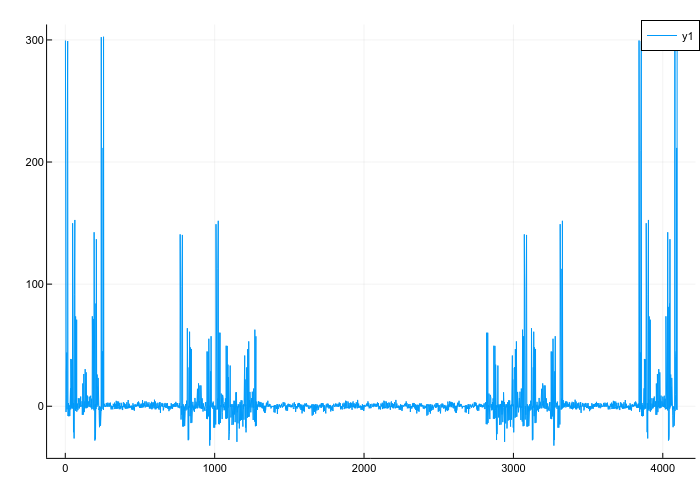

In [100]:
plot( (real.(oo))) 

In [102]:
xyz_from_i(49)

(1, 4, 1)

In [101]:
Nx = 16
Ny = Nx
Nz = Nx
@inline function xyz_from_i(i)
    i0 = i - 1
    x = mod(i0, Nx) + 1
    y = mod(div(i0, Nx), Ny) + 1
    z = div(i0, Nx*Ny) + 1

    return x, y, z
end

xyz_from_i (generic function with 1 method)

In [85]:
plotlyjs()

WebIO._IJuliaInit()

Plots.PlotlyJSBackend()

In [216]:
k_mpo_1, k_mpo_2 = shifting_ops(3*L+1,site_hermi );
 
#block matrix MPO for later usaged
I_rup = exponential_shift(k_mpo_1,3*L); #((0,I),(0,0))
I_ldn = exponential_shift(k_mpo_2,3*L); #((0,0),(I,0))
 

In [217]:
function up_down_vecs(index,sites)
    N = length(sites)

    up_vec = randomMPS(sites,to_binary_vector(Int(index),Int(log2(2^N))))
    dn_vec = randomMPS(sites,to_binary_vector(Int(index + 2^(N-1)),Int(log2(2^N))))
    
    return up_vec, dn_vec
end
function KPM_Tn_NH_bysite(H,n,index,scale,sites)
    N = 2* n 
    Ham_n = H/scale
    up_vec,dn_vec = up_down_vecs(index,sites)
    T_k_minus_2 = up_vec
    T_k_minus_1 = apply(Ham_n,up_vec)

    T_k_minus_1_partial = dn_vec
    T_k_minus_2_partial = 0*randomMPS(sites)

    Tn_list = [T_k_minus_2,T_k_minus_1]
    Tn_paritial_list = [T_k_minus_2_partial,T_k_minus_1_partial]

    for k in 1:N
        if k == 1
            T_k = T_k_minus_2
            T_k_partial = T_k_minus_2_partial 
        elseif k == 2
            T_k = T_k_minus_1
            T_k_partial = T_k_minus_1_partial 
        else
            T_k_partial = +( apply(2 * I_ldn, T_k_minus_1; maxdim=100) , 2* apply(Ham_n,T_k_minus_1_partial; maxdim=100);  maxdim=100)
            T_k_partial = +(T_k_partial, -T_k_minus_2_partial; maxdim=100)
            
            T_k_minus_2_partial = T_k_minus_1_partial
            T_k_minus_1_partial = T_k_partial
     
            T_k = +(2 * apply(Ham_n, T_k_minus_1; maxdim=100) , -T_k_minus_2; maxdim=100) 

            T_k_minus_2 = T_k_minus_1 
            T_k_minus_1 =  T_k  
            push!(Tn_paritial_list,T_k_partial)
        end
    end
    return   Tn_paritial_list 
end

KPM_Tn_NH_bysite (generic function with 1 method)

In [218]:
function get_energy_from_T_MPS(Tn_partial_list,nn,index,sites)
  
    N = 2*nn
    jackson_kernel = [(N - n+1) * cos(π * n / (N+1)) + sin(π * n / (N+1)) / tan(π / (N+1)) for n in 0:N-1 ]
 
    # Compute electronic density
    A = Tn_partial_list[1]  
    for l in 2:2:N
        order = (-1)^(((l)/2 -1))
        A = +(A,  order *  Tn_partial_list[l]  * jackson_kernel[l-1] ; maxdim=100)
      
        
    end
    
    A  *= 2/(π^2 * (N+1))
    up_vec,dn_vec = up_down_vecs(index,sites) 
    dos_point = inner(dn_vec',A)
    
    return  dos_point
end

get_energy_from_T_MPS (generic function with 1 method)

In [219]:
site_index = [3]
o = []
for si in site_index 
    lis = KPM_Tn_NH_bysite(hermi_ham,300,si,12,site_hermi)
    dos_p = get_energy_from_T_MPS(lis,300,si,site_hermi)
    println((dos_p ))
    push!(o,dos_p)
end

2951.268151089379 - 1.1526275345745626e-7im


In [173]:
psi0 = random_mps(site_hermi;linkdims=10)

nsweeps = 15
maxdim = [10,20,100,100,200]
cutoff = [1E-10]

energy,psi = dmrg(hermi_ham,psi0;nsweeps,maxdim,cutoff)



After sweep 1 energy=-10.322910595508201  maxlinkdim=10 maxerr=4.00E-03 time=0.012
After sweep 2 energy=-10.713917004975857  maxlinkdim=20 maxerr=9.40E-06 time=0.009
After sweep 3 energy=-10.810482101036841  maxlinkdim=32 maxerr=7.72E-16 time=0.016
After sweep 4 energy=-10.824221782399285  maxlinkdim=31 maxerr=1.42E-11 time=0.015
After sweep 5 energy=-10.826334931270146  maxlinkdim=30 maxerr=5.16E-11 time=0.014
After sweep 6 energy=-10.826767756778532  maxlinkdim=29 maxerr=7.93E-11 time=0.015
After sweep 7 energy=-10.826876909305032  maxlinkdim=29 maxerr=5.52E-11 time=0.015
After sweep 8 energy=-10.826908381603536  maxlinkdim=28 maxerr=9.11E-11 time=0.010
After sweep 9 energy=-10.826918056309879  maxlinkdim=28 maxerr=6.60E-11 time=0.015
After sweep 10 energy=-10.826921185521954  maxlinkdim=28 maxerr=5.54E-11 time=0.014
After sweep 11 energy=-10.826922256811836  maxlinkdim=28 maxerr=5.81E-11 time=0.015
After sweep 12 energy=-10.826922645830747  maxlinkdim=28 maxerr=5.55E-11 time=0.014
A

(-10.826922875502301, MPS
[1] ((dim=2|id=375|"Link,l=1"), (dim=2|id=433|"Qubit,Site,n=1"))
[2] ((dim=4|id=502|"Link,l=2"), (dim=2|id=834|"Qubit,Site,n=1"), (dim=2|id=375|"Link,l=1"))
[3] ((dim=2|id=444|"Qubit,Site,n=2"), (dim=8|id=764|"Link,l=3"), (dim=4|id=502|"Link,l=2"))
[4] ((dim=2|id=929|"Qubit,Site,n=3"), (dim=16|id=442|"Link,l=4"), (dim=8|id=764|"Link,l=3"))
[5] ((dim=2|id=956|"Qubit,Site,n=1"), (dim=28|id=446|"Link,l=5"), (dim=16|id=442|"Link,l=4"))
[6] ((dim=2|id=361|"Qubit,Site,n=2"), (dim=16|id=161|"Link,l=6"), (dim=28|id=446|"Link,l=5"))
[7] ((dim=2|id=726|"Qubit,Site,n=3"), (dim=8|id=570|"Link,l=7"), (dim=16|id=161|"Link,l=6"))
[8] ((dim=2|id=345|"Qubit,Site,n=4"), (dim=4|id=117|"Link,l=8"), (dim=8|id=570|"Link,l=7"))
[9] ((dim=2|id=553|"Qubit,Site,n=5"), (dim=2|id=609|"Link,l=9"), (dim=4|id=117|"Link,l=8"))
[10] ((dim=2|id=301|"Qubit,Site,n=6"), (dim=2|id=609|"Link,l=9"))
)

In [77]:
function get_spectrum_singele(ex,ey,npole, tot_mpo,scale)
 

    Z = zeros(Complex{Float64}, 1,1)   # 用来存 DOS，行对应 y，列对应 x

 
    omega = ex + 1im * ey
    H_mpo = hermitized_mpo(omega, tot_mpo)         # 注意避免函数名和变量名重名
    p_list = KPM_Tn_NH(H_mpo, npole,scale)
    A,dos = get_energy_from_Tnp(p_list, npole)

    

    return p_list, A,dos 
end

get_spectrum_singele (generic function with 1 method)

In [83]:
lis, A,dos = get_spectrum_singele(0,4.5,  150,  tot_mpo,12)

6
20
51
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100


(MPO[MPO
[1] ((dim=2|id=192|"Qubit,Site,n=1")', (dim=2|id=192|"Qubit,Site,n=1"), (dim=2|id=120|"Link,l=1"))
[2] ((dim=2|id=305|"Qubit,Site,n=2")', (dim=2|id=305|"Qubit,Site,n=2"), (dim=1|id=104|"Link,l=2"), (dim=2|id=120|"Link,l=1"))
[3] ((dim=2|id=946|"Qubit,Site,n=3")', (dim=2|id=946|"Qubit,Site,n=3"), (dim=1|id=364|"Link,l=3"), (dim=1|id=104|"Link,l=2"))
[4] ((dim=2|id=208|"Qubit,Site,n=4")', (dim=2|id=208|"Qubit,Site,n=4"), (dim=1|id=662|"Link,l=4"), (dim=1|id=364|"Link,l=3"))
[5] ((dim=2|id=203|"Qubit,Site,n=5")', (dim=2|id=203|"Qubit,Site,n=5"), (dim=1|id=581|"Link,l=5"), (dim=1|id=662|"Link,l=4"))
[6] ((dim=2|id=656|"Qubit,Site,n=6")', (dim=2|id=656|"Qubit,Site,n=6"), (dim=1|id=86|"Link,l=6"), (dim=1|id=581|"Link,l=5"))
[7] ((dim=2|id=806|"Qubit,Site,n=7")', (dim=2|id=806|"Qubit,Site,n=7"), (dim=1|id=983|"Link,l=7"), (dim=1|id=86|"Link,l=6"))
[8] ((dim=2|id=904|"Qubit,Site,n=8")', (dim=2|id=904|"Qubit,Site,n=8"), (dim=1|id=853|"Link,l=8"), (dim=1|id=983|"Link,l=7"))
[9] ((dim=2|

In [84]:
xvals = range(0, (2^(10) - 1); length=2^(10))
f(x) =  real((inner(randomMPS(sites,to_binary_vector(Int(x),Int(log2(2^11))))',A,randomMPS(sites,to_binary_vector(Int(x),Int(log2(2^11 )))))))
 

qtt, ranks, errors = quanticscrossinterpolate(Float64, f,  xvals; tolerance=1e-8)

c = []
for i in 1:2^10
    push!(c,qtt(i))
end
d = reshape(c,32,32)

32×32 Matrix{Any}:
 114.441      -33.8422      -0.0580568  …  -33.9398     122.833
 -30.4352       0.316235    -0.694256       -0.0340519  -33.4066
  -0.207937    -0.263406     3.2414         -0.252005    -0.0627271
  -1.01814      0.0836685    0.924256        0.41735      0.0283981
  17.173       -1.66252     -0.0621929      -2.43808     17.0969
  -5.01963     -0.434668     0.269416   …    0.120399    -7.10389
  -0.0566303    0.267423    -2.60735         0.0828233    0.0604624
   0.378698    -0.526757     2.18892        -0.395233    -0.00180507
  -5.80092      0.936472    -0.099381        3.57081     -2.42168
   1.79879     -0.441529    -0.0536226      -0.0599854    2.98455
   0.0991166    0.856597    -2.41578    …    0.629087     0.243158
  -0.0366335    0.374266    -3.53541         0.298995     0.326407
   3.19446     -2.00639      0.306886       -1.6305       2.98426
   ⋮                                    ⋱    ⋮          
   0.0772326    0.351261    -3.81327    …    0.36745      0